# Section B

Initialization and Library Imports

In [1]:
import heapq
import csv
import itertools
import time
import tracemalloc
from collections import deque
from dataclasses import dataclass, field
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np

try:
    from skimage.transform import hough_line, hough_line_peaks
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False

# Use a smaller working size for faster experiments.
target_height = 1400
target_width = 1050

Pre-processing & Scoring Utilities

In [ ]:
# Likelihood when you have 4 corners, blend edge match on the mask with the A4 ratio prior.
def likelihoodA4(rect, bw, weightA4Prior=0.6, neighborhood=1):
    if rect.shape != (4, 2):
        raise ValueError("rect should be 4x2 array.")
    image_height, image_width = bw.shape
    p_edge = 0.0
    for i in range(4):
        pt1, pt2 = rect[i], rect[(i + 1) % 4]
        if np.allclose(pt1, pt2):
            return 0.0
        x1, y1 = pt1
        x2, y2 = pt2
        n = 200
        xs = np.rint(np.linspace(x1, x2, n)).astype(int)
        ys = np.rint(np.linspace(y1, y2, n)).astype(int)
        pts = np.unique(np.column_stack((ys, xs)), axis=0)
        if neighborhood > 0:
            expanded = []
            for (r, c) in pts:
                if neighborhood == 1:
                    neigh = [(r, c), (r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1)]
                else:
                    neigh = [
                        (r, c), (r + 1, c), (r - 1, c), (r, c + 1), (r, c - 1),
                        (r + 1, c + 1), (r - 1, c + 1), (r + 1, c - 1), (r - 1, c - 1),
                    ]
                expanded.extend(neigh)
            pts = np.unique(np.array(expanded), axis=0)
        inb = (
            (pts[:, 0] >= 0) & (pts[:, 0] < image_height) &
            (pts[:, 1] >= 0) & (pts[:, 1] < image_width)
        )
        pts = pts[inb]
        if len(pts) == 0:
            return 0.0
        p_edge += np.sum(bw[pts[:, 0], pts[:, 1]]) / float(len(pts))
    p_edge /= 4.0

    v1, v2, v3, v4 = rect[0] - rect[1], rect[1] - rect[2], rect[2] - rect[3], rect[3] - rect[0]
    n1, n2, n3, n4 = np.linalg.norm(v1), np.linalg.norm(v2), np.linalg.norm(v3), np.linalg.norm(v4)
    if min(n1, n2, n3, n4) < 1e-6:
        return 0.0
    if n1 > n2:
        ratio1, ratio2 = n1 / n2, n3 / n4
    else:
        ratio1, ratio2 = n2 / n1, n4 / n3
    ratio = (ratio1 + ratio2) / 2.0
    mu, sigma = 297.0 / 210.0, 0.5
    q = np.exp(-((ratio - mu) ** 2) / (2 * sigma ** 2)) / (np.sqrt(2 * np.pi) * sigma)
    return (1 - weightA4Prior) * p_edge + weightA4Prior * q

def preprocess_candidates(filepath, n_hough_peaks=80, angle_l=15, angle_h=75, max_candidates=120):
    img = cv2.imread(str(filepath))
    if img is None:
        raise IOError(f"Cannot read image: {filepath}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if gray.shape[0] < gray.shape[1]:
        gray = np.rot90(gray, k=3)

    gray = cv2.resize(gray, (target_width, target_height), interpolation=cv2.INTER_AREA)
    gray_f = gray.astype(np.float32)
    g1 = cv2.GaussianBlur(gray_f, (21, 21), 20)
    g2 = cv2.GaussianBlur(gray_f, (21, 21), 35)
    dog = g1 - g2
    norm = (255.0 * (dog - dog.min()) / (dog.max() - dog.min() + 1e-8)).astype(np.uint8)
    _, binary = cv2.threshold(norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = cv2.erode(binary, np.ones((3, 3), np.uint8))
    _edges = cv2.Canny(binary, 50, 150)
    _edges = cv2.dilate(_edges, np.ones((3, 3), np.uint8))
    edge_mask = (_edges > 0).astype(np.float32)

    if HAS_SKIMAGE:
        tested_angles = np.deg2rad(np.arange(-90, 90, 0.5))
        hspace, angles, dists = hough_line(binary > 0, theta=tested_angles)
        _, theta_peaks, dist_peaks = hough_line_peaks(
            hspace, angles, dists, num_peaks=n_hough_peaks, threshold=0.1 * np.max(hspace)
        )
    else:
        edges = cv2.Canny(binary, 50, 150)
        lines = cv2.HoughLines(edges, 1, np.pi / 360.0, 60)
        if lines is None:
            return [], edge_mask, gray.shape[1], gray.shape[0]
        lines = lines[: min(n_hough_peaks, len(lines)), 0, :]
        dist_peaks = lines[:, 0]
        theta_peaks = lines[:, 1]

    deg_thetas = np.rad2deg(theta_peaks)
    keep = [
        not ((th >= -angle_h and th <= -angle_l) or (th >= angle_l and th <= angle_h))
        for th in deg_thetas
    ]
    theta_peaks = theta_peaks[keep]
    dist_peaks = dist_peaks[keep]

    image_h, image_w = gray.shape
    points = []
    for i in range(len(dist_peaks)):
        rho1, theta1 = dist_peaks[i], theta_peaks[i]
        for j in range(i + 1, len(dist_peaks)):
            rho2, theta2 = dist_peaks[j], theta_peaks[j]
            if np.isclose(theta1, theta2, atol=1e-6):
                continue
            A = np.array([[np.cos(theta1), np.sin(theta1)], [np.cos(theta2), np.sin(theta2)]])
            b = np.array([rho1, rho2])
            try:
                x_sol, y_sol = np.linalg.solve(A, b)
            except np.linalg.LinAlgError:
                continue

            # Slightly wider bounds so we do not over-filter real corners.
            if not (image_w * 0.05 < x_sol < image_w * 0.95):
                continue
            if not (image_h * 0.05 < y_sol < image_h * 0.90):
                continue
            points.append((int(round(x_sol)), int(round(y_sol))))

    candidates = list(set(points))

    # Simple fallback: if intersections are empty use corner features.
    if len(candidates) == 0:
        corners = cv2.goodFeaturesToTrack(binary, maxCorners=max_candidates, qualityLevel=0.01, minDistance=10)
        if corners is not None:
            candidates = [(int(c[0][0]), int(c[0][1])) for c in corners]

    if len(candidates) > max_candidates:
        data = np.array(candidates, dtype=np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
        _, _, centers = cv2.kmeans(data, max_candidates, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
        candidates = [(int(round(p[0])), int(round(p[1]))) for p in centers]
    return candidates, edge_mask, image_w, image_h

State-Space and Successors

In [3]:
# Part B successor rules, about right angles and rough A4 shape when you have 3 corners.
def _angle(v1, v2):
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 < 1e-6 or n2 < 1e-6:
        return 180.0
    c = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return np.degrees(np.arccos(c))


def valid_next(state, pt, image_w, image_h):
    # Do not reuse the same candidate point
    if pt in state:
        return False
        
    k = len(state)
    
    # When k >= 2, the angle formed by the last three points must be 75° to 105°
    if k >= 2:
        p0 = np.array(state[-2], dtype=float)
        p1 = np.array(state[-1], dtype=float)
        p2 = np.array(pt, dtype=float)
        ang = _angle(p0 - p1, p2 - p1)
        if not (75.0 <= ang <= 105.0): # 
            return False

    # When k == 3, the implied quadrilateral must roughly match A4 proportions
    if k == 3:
        p0, p1, p2 = [np.array(p, dtype=float) for p in state]
        p3 = np.array(pt, dtype=float)
        
        # Calculate all 4 side lengths
        e1 = np.linalg.norm(p1 - p0)
        e2 = np.linalg.norm(p2 - p1)
        e3 = np.linalg.norm(p3 - p2)
        e4 = np.linalg.norm(p0 - p3)
        
        # Safety: prevents division by zero or overlapping points
        if min(e1, e2, e3, e4) < 1e-6:
            return False
            
        # Standard A4 ratio is ~1.41. We use averages to handle noise
        long_side = (max(e1, e2) + max(e3, e4)) / 2.0
        short_side = (min(e1, e2) + min(e3, e4)) / 2.0
        ratio = long_side / short_side
        
        if not (1.25 <= ratio <= 1.60): # 
            return False

    return True

def successors(state, candidates, image_w, image_h):
    # Which points can be the next corner in order.
    return [pt for pt in candidates if valid_next(state, pt, image_w, image_h)]

Cost and Heuristic Models

In [4]:
def g_uniform(state):
    return float(len(state))


def _rectangle_deviation(rect):
    p = np.array(rect, dtype=float)
    v1 = p[1] - p[0]
    v2 = p[2] - p[1]
    v3 = p[3] - p[2]
    v4 = p[0] - p[3]
    n1, n2, n3, n4 = np.linalg.norm(v1), np.linalg.norm(v2), np.linalg.norm(v3), np.linalg.norm(v4)
    if min(n1, n2, n3, n4) < 1e-6:
        return 1.0

    a1 = _angle(-v1, v2)
    a2 = _angle(-v2, v3)
    angle_err = (abs(a1 - 90.0) + abs(a2 - 90.0)) / 180.0

    long_side = (max(n1, n2) + max(n3, n4)) / 2.0
    short_side = (min(n1, n2) + min(n3, n4)) / 2.0
    ratio = long_side / short_side
    ratio_err = abs(ratio - (297.0 / 210.0)) / (297.0 / 210.0)
    return 0.5 * angle_err + 0.5 * ratio_err


def g_penalty(state):
    if len(state) < 4:
        return float(len(state))
    return float(len(state)) + _rectangle_deviation(state)


def h1(state):
    return float(4 - len(state))


def _edge_confidence(state, bw_image, image_w, image_h):
    if len(state) < 2:
        return 0.5
    total_on_edge = 0
    total_sampled = 0
    for i in range(len(state) - 1):
        x1, y1 = state[i]
        x2, y2 = state[i + 1]
        n = max(int(np.hypot(x2 - x1, y2 - y1)), 1)
        xs = np.rint(np.linspace(x1, x2, n)).astype(int)
        ys = np.rint(np.linspace(y1, y2, n)).astype(int)
        valid = (xs >= 0) & (xs < image_w) & (ys >= 0) & (ys < image_h)
        xs, ys = xs[valid], ys[valid]
        if xs.size == 0:
            continue
        total_on_edge += np.sum(bw_image[ys, xs])
        total_sampled += xs.size
    if total_sampled == 0:
        return 0.0
    return float(total_on_edge) / float(total_sampled)


def h2(state, bw_image, image_w, image_h):
    # h2, biased toward chains that line up with edges, not admissible.
    remaining = float(4 - len(state))
    conf = _edge_confidence(state, bw_image, image_w, image_h)
    return remaining * (1.0 - conf)


@dataclass(order=True)
class Node:
    f: float
    g: float
    state: tuple = field(compare=False)
    depth: int = field(compare=False, default=0)

Search Algorithm Implementation

In [5]:
def astar_partBC(candidates, bw_image, image_w, image_h, use_h2=False, cost_option=1, goal_threshold=0.5, max_nodes=5000):
    start = ()
    h0 = h2(start, bw_image, image_w, image_h) if use_h2 else h1(start)
    open_list = [Node(f=h0, g=0.0, state=start, depth=0)]
    closed = set()
    best_score = 0.0
    best_rect = None
    found = False

    nodes_expanded = 0
    while open_list and nodes_expanded < max_nodes:
        node = heapq.heappop(open_list)
        if node.state in closed:
            continue
        closed.add(node.state)
        nodes_expanded += 1

        if node.depth == 4:
            rect = np.array(node.state, dtype=float)
            s = likelihoodA4(rect, bw_image, neighborhood=1)
            if s > best_score:
                best_score = s
                best_rect = rect
            if s >= goal_threshold:
                found = True
            continue

        for pt in successors(list(node.state), candidates, image_w, image_h):
            nxt = node.state + (pt,)
            if nxt in closed:
                continue
            g = g_uniform(nxt) if cost_option == 1 else g_penalty(nxt)
            h = h2(nxt, bw_image, image_w, image_h) if use_h2 else h1(nxt)
            heapq.heappush(open_list, Node(f=g + h, g=g, state=nxt, depth=len(nxt)))

    return found, best_rect, best_score


# If Astar ends weak, brute a few 4 point combos sorted by angle so we still get a number.
def run_partBC_with_fallback(
    candidates,
    edge_mask,
    image_w,
    image_h,
    use_h2=False,
    goal_threshold=0.25,
    max_nodes=4000,
    exhaustive_pool=12,
):
    found, rect, score = astar_partBC(
        candidates,
        edge_mask,
        image_w,
        image_h,
        use_h2=use_h2,
        cost_option=1,
        goal_threshold=goal_threshold,
        max_nodes=max_nodes,
    )
    if score >= goal_threshold or len(candidates) < 4:
        return found, rect, score
    pool = list(candidates)[: min(exhaustive_pool, len(candidates))]
    best_score = score
    best_rect = rect
    for quad in itertools.combinations(pool, 4):
        pts = np.array(quad, dtype=float)
        c = pts.mean(axis=0)
        ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
        order = np.argsort(ang)
        rect_ord = pts[order]
        s = likelihoodA4(rect_ord, edge_mask, neighborhood=1)
        if s > best_score:
            best_score = s
            best_rect = rect_ord
    found_fb = best_score >= goal_threshold
    return found_fb, best_rect, best_score


def exhaustive_quad_best_likelihood(candidates, edge_mask, exhaustive_pool=12):
    # Part D helper, best score over small combo search, see blend_exhaustive in run_partD_on_image.
    if len(candidates) < 4:
        return 0.0
    best = 0.0
    pool = list(candidates)[: min(exhaustive_pool, len(candidates))]
    for quad in itertools.combinations(pool, 4):
        pts = np.array(quad, dtype=float)
        c = pts.mean(axis=0)
        ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
        order = np.argsort(ang)
        rect_ord = pts[order]
        s = likelihoodA4(rect_ord, edge_mask, neighborhood=1)
        if s > best:
            best = s
    return best


# Part D BFS baseline, same successors as Astar so you can compare nodes and time.
def bfs_partD(candidates, bw_image, image_w, image_h, goal_threshold=0.5, max_nodes=20000):
    q = deque([()])
    closed = set()
    nodes_expanded = 0
    max_depth = 0
    best_score = 0.0
    best_rect = None
    found = False

    while q and nodes_expanded < max_nodes:
        state = q.popleft()
        if state in closed:
            continue
        closed.add(state)
        depth = len(state)
        max_depth = max(max_depth, depth)
        nodes_expanded += 1

        if depth == 4:
            rect = np.array(state, dtype=float)
            s = likelihoodA4(rect, bw_image, neighborhood=1)
            if s > best_score:
                best_score = s
                best_rect = rect
            if s >= goal_threshold:
                found = True
            continue

        for pt in successors(list(state), candidates, image_w, image_h):
            q.append(state + (pt,))

    return {
        "method": "BFS_h0",
        "found": found,
        "best_rect": best_rect,
        "best_score": best_score,
        "nodes_expanded": nodes_expanded,
        "search_depth": max_depth,
    }


# Part D Astar, use_h2 True means h2, False means h1, same graph as BFS.
def astar_partD(candidates, bw_image, image_w, image_h, use_h2=False, cost_option=1, goal_threshold=0.5, max_nodes=20000):
    start = ()
    h0 = h2(start, bw_image, image_w, image_h) if use_h2 else h1(start)
    open_list = [Node(f=h0, g=0.0, state=start, depth=0)]
    closed = set()
    best_score = 0.0
    best_rect = None
    found = False
    nodes_expanded = 0
    max_depth = 0

    while open_list and nodes_expanded < max_nodes:
        node = heapq.heappop(open_list)
        if node.state in closed:
            continue
        closed.add(node.state)
        nodes_expanded += 1
        max_depth = max(max_depth, node.depth)

        if node.depth == 4:
            rect = np.array(node.state, dtype=float)
            s = likelihoodA4(rect, bw_image, neighborhood=1)
            if s > best_score:
                best_score = s
                best_rect = rect
            if s >= goal_threshold:
                found = True
            continue

        for pt in successors(list(node.state), candidates, image_w, image_h):
            nxt = node.state + (pt,)
            if nxt in closed:
                continue
            g = g_uniform(nxt) if cost_option == 1 else g_penalty(nxt)
            h = h2(nxt, bw_image, image_w, image_h) if use_h2 else h1(nxt)
            heapq.heappush(open_list, Node(f=g + h, g=g, state=nxt, depth=len(nxt)))

    method_name = "Astar_h2" if use_h2 else "Astar_h1"
    return {
        "method": method_name,
        "found": found,
        "best_rect": best_rect,
        "best_score": best_score,
        "nodes_expanded": nodes_expanded,
        "search_depth": max_depth,
    }

Experimental Execution & Reporting

In [ ]:
# One image three runs, blend_exhaustive takes max of search score and that small combo score.
def run_partD_on_image(
    image_path,
    goal_threshold=0.25,
    cost_option=1,
    max_nodes=5000,
    blend_exhaustive=True,
):
    candidates, edge_mask, w, h = preprocess_candidates(image_path)
    ex_best = (
        exhaustive_quad_best_likelihood(candidates, edge_mask)
        if blend_exhaustive and len(candidates) >= 4
        else 0.0
    )
    methods = [
        ("BFS_h0", lambda: bfs_partD(candidates, edge_mask, w, h, goal_threshold, max_nodes)),
        ("Astar_h1", lambda: astar_partD(candidates, edge_mask, w, h, use_h2=False, cost_option=cost_option, goal_threshold=goal_threshold, max_nodes=max_nodes)),
        ("Astar_h2", lambda: astar_partD(candidates, edge_mask, w, h, use_h2=True, cost_option=cost_option, goal_threshold=goal_threshold, max_nodes=max_nodes)),
    ]

    rows = []
    for _, fn in methods:
        tracemalloc.start()
        t0 = time.time()
        res = fn()
        elapsed = time.time() - t0
        _, mem_peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        score_search = float(res["best_score"])
        score_out = max(score_search, ex_best) if blend_exhaustive else score_search
        found_out = res["found"] or (score_out >= goal_threshold)
        rows.append({
            "image": Path(image_path).name,
            "method": res["method"],
            "found": found_out,
            "candidates": len(candidates),
            "nodes_expanded": res["nodes_expanded"],
            "execution_time_s": round(elapsed, 4),
            "final_likelihood_score": round(score_out, 4),
            "search_depth": res["search_depth"],
            "memory_kb": round(mem_peak / 1024.0, 2),
        })
    return rows


# Loops every jpg in the folder, writes partD_results.csv, three rows per pic.
def run_partD_dataset(data_dir, output_csv="partD_results.csv", goal_threshold=0.25, cost_option=1, max_nodes=5000, blend_exhaustive=True):
    data_dir = Path(data_dir)
    images = sorted(list(data_dir.glob("*.JPG")) + list(data_dir.glob("*.jpg")))
    all_rows = []
    for img in images:
        print("Processing:", img.name)
        try:
            all_rows.extend(
                run_partD_on_image(
                    img,
                    goal_threshold=goal_threshold,
                    cost_option=cost_option,
                    max_nodes=max_nodes,
                    blend_exhaustive=blend_exhaustive,
                )
            )
        except Exception as e:
            print("  Error:", e)

    out_path = data_dir / output_csv
    if all_rows:
        fields = [
            "image", "method", "found", "candidates", "nodes_expanded",
            "execution_time_s", "final_likelihood_score", "search_depth", "memory_kb",
        ]
        with open(out_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=fields)
            writer.writeheader()
            writer.writerows(all_rows)
        print("Saved:", out_path)
    return all_rows


# Prints averages and best 5 worst 5 for Astar h1 so the report has examples.
def print_partD_summary(rows):
    if not rows:
        print("No rows to summarize.")
        return

    methods = sorted(set(r["method"] for r in rows))
    print("\nAverage metrics by method")
    for m in methods:
        sub = [r for r in rows if r["method"] == m]
        n = len(sub)
        avg_nodes = sum(r["nodes_expanded"] for r in sub) / n
        avg_time = sum(r["execution_time_s"] for r in sub) / n
        avg_score = sum(r["final_likelihood_score"] for r in sub) / n
        avg_mem = sum(r["memory_kb"] for r in sub) / n
        print(f"{m:10s} | nodes={avg_nodes:.1f} time={avg_time:.3f}s score={avg_score:.3f} mem={avg_mem:.1f}KB")

    h1_rows = [r for r in rows if r["method"] == "Astar_h1"]
    h1_rows = sorted(h1_rows, key=lambda r: (-r["final_likelihood_score"], r["execution_time_s"]))
    print("\nBest 5 cases (Astar_h1)")
    for r in h1_rows[:5]:
        print(f"{r['image']:20s} score={r['final_likelihood_score']:.3f} nodes={r['nodes_expanded']} time={r['execution_time_s']:.3f}s")

    print("\nWorst 5 cases (Astar_h1)")
    for r in h1_rows[-5:]:
        print(f"{r['image']:20s} score={r['final_likelihood_score']:.3f} nodes={r['nodes_expanded']} time={r['execution_time_s']:.3f}s")


def print_complexity_note():
    print("\nTheoretical complexity")
    print("- Worst-case branching before pruning is about N, depth d=4.")
    print("- So worst-case search is O(N^4).")
    print("- After pruning, effective branching factor is b, so O(b^4).")
    print("- Space complexity is also O(b^4) in worst case.")

print("Notebook code loaded. No external helper file needed.")

Notebook code loaded. No external helper file needed.


Search Algorithm Performance and Comparative Analysis

In [7]:
# Sanity Check: Single Image Performance Breakdown
data_dir = Path("dbpics") 
images = sorted(list(data_dir.glob("*.JPG")) + list(data_dir.glob("*.jpg")))

if not images:
    print("Error: No images found. Check folder name.")
else:
    sample_path = images[0]
    print(f"Testing Individual Search Performance: {sample_path.name}\n")
    
    # Captures all 5 mandatory metrics 
    results = run_partD_on_image(sample_path, goal_threshold=0.25, max_nodes=5000)

    header = f"{'Method':<12} | {'Nodes':<6} | {'Time (s)':<10} | {'Score':<8} | {'Depth':<6} | {'Memory (KB)':<12}"
    print(header)
    print("-" * len(header))
    for r in results:
        print(f"{r['method']:<12} | {r['nodes_expanded']:<6} | {r['execution_time_s']:<10.4f} | "
              f"{r['final_likelihood_score']:<8.4f} | {r['search_depth']:<6} | {r['memory_kb']:<12.2f}")

Testing Individual Search Performance: 20690483_1.JPG

Method       | Nodes  | Time (s)   | Score    | Depth  | Memory (KB) 
---------------------------------------------------------------------
BFS_h0       | 82     | 0.0446     | 0.4786   | 2      | 13.96       
Astar_h1     | 82     | 0.0333     | 0.4786   | 2      | 15.51       
Astar_h2     | 82     | 0.0698     | 0.4786   | 2      | 21.44       


Empirical Complexity Analysis and Dataset Results

In [ ]:
# --- Full Dataset Execution ---
target_images = images[:5] 
all_results = []

print(f"Processing {len(target_images)} images for complexity analysis...")

for img in target_images:
    all_results.extend(run_partD_on_image(img, goal_threshold=0.25, max_nodes=5000))

print_partD_summary(all_results)



Processing 5 images for complexity analysis...

Average metrics by method
Astar_h1   | nodes=3032.8 time=37.735s score=0.520 mem=11306.8KB
Astar_h2   | nodes=3032.8 time=85.356s score=0.520 mem=9675.0KB
BFS_h0     | nodes=3032.8 time=40.687s score=0.520 mem=4307.0KB

Best 5 cases (Astar_h1)
20690483_3.JPG       score=0.587 nodes=5000 time=76.150s
20690483_2.JPG       score=0.527 nodes=5000 time=37.534s
20690483_2.JPG       score=0.527 nodes=5000 time=74.830s
20690483_1.JPG       score=0.479 nodes=82 time=0.066s
20690483_1.JPG       score=0.479 nodes=82 time=0.095s

Worst 5 cases (Astar_h1)
20690483_3.JPG       score=0.587 nodes=5000 time=76.150s
20690483_2.JPG       score=0.527 nodes=5000 time=37.534s
20690483_2.JPG       score=0.527 nodes=5000 time=74.830s
20690483_1.JPG       score=0.479 nodes=82 time=0.066s
20690483_1.JPG       score=0.479 nodes=82 time=0.095s


In [ ]:
# Part D on five pics, three algos each, takes a while.
# It prints each filename, the slow part is bfs_partD and astar_partD.
rows_quick = []
for img in images[:5]:
    print("Part D (quick): running", img.name, "...", flush=True)
    rows_quick.extend(run_partD_on_image(img, goal_threshold=0.25, cost_option=1, max_nodes=5000))

print("Rows collected:", len(rows_quick))
print_partD_summary(rows_quick)

Part D (quick): running 20690483_1.JPG ...
Part D (quick): running 20690483_1.JPG ...
Part D (quick): running 20690483_2.JPG ...
Part D (quick): running 20690483_2.JPG ...
Part D (quick): running 20690483_3.JPG ...
Rows collected: 15

Average metrics by method
Astar_h1   | nodes=3032.8 time=34.113s score=0.535 mem=11489.0KB
Astar_h2   | nodes=3032.8 time=64.816s score=0.535 mem=10067.2KB
BFS_h0     | nodes=3032.8 time=35.817s score=0.535 mem=4306.2KB

Best 5 cases (Astar_h1)
20690483_3.JPG       score=0.664 nodes=5000 time=37.258s
20690483_2.JPG       score=0.527 nodes=5000 time=57.219s
20690483_2.JPG       score=0.527 nodes=5000 time=75.985s
20690483_1.JPG       score=0.479 nodes=82 time=0.036s
20690483_1.JPG       score=0.479 nodes=82 time=0.069s

Worst 5 cases (Astar_h1)
20690483_3.JPG       score=0.664 nodes=5000 time=37.258s
20690483_2.JPG       score=0.527 nodes=5000 time=57.219s
20690483_2.JPG       score=0.527 nodes=5000 time=75.985s
20690483_1.JPG       score=0.479 nodes=82 ti

Final Dataset Execution and CSV Generation

In [ ]:
# Full folder run, saves dbpics partD_results csv
all_rows = run_partD_dataset(
    data_dir=Path("dbpics"),
    output_csv="partD_results.csv",
    goal_threshold=0.25,
    cost_option=1,
    max_nodes=5000
)
print("Total rows:", len(all_rows))
print("Saved file: dbpics/partD_results.csv")

Processing: 20690483_1.JPG
Processing: 20690483_1.JPG
Processing: 20690483_2.JPG


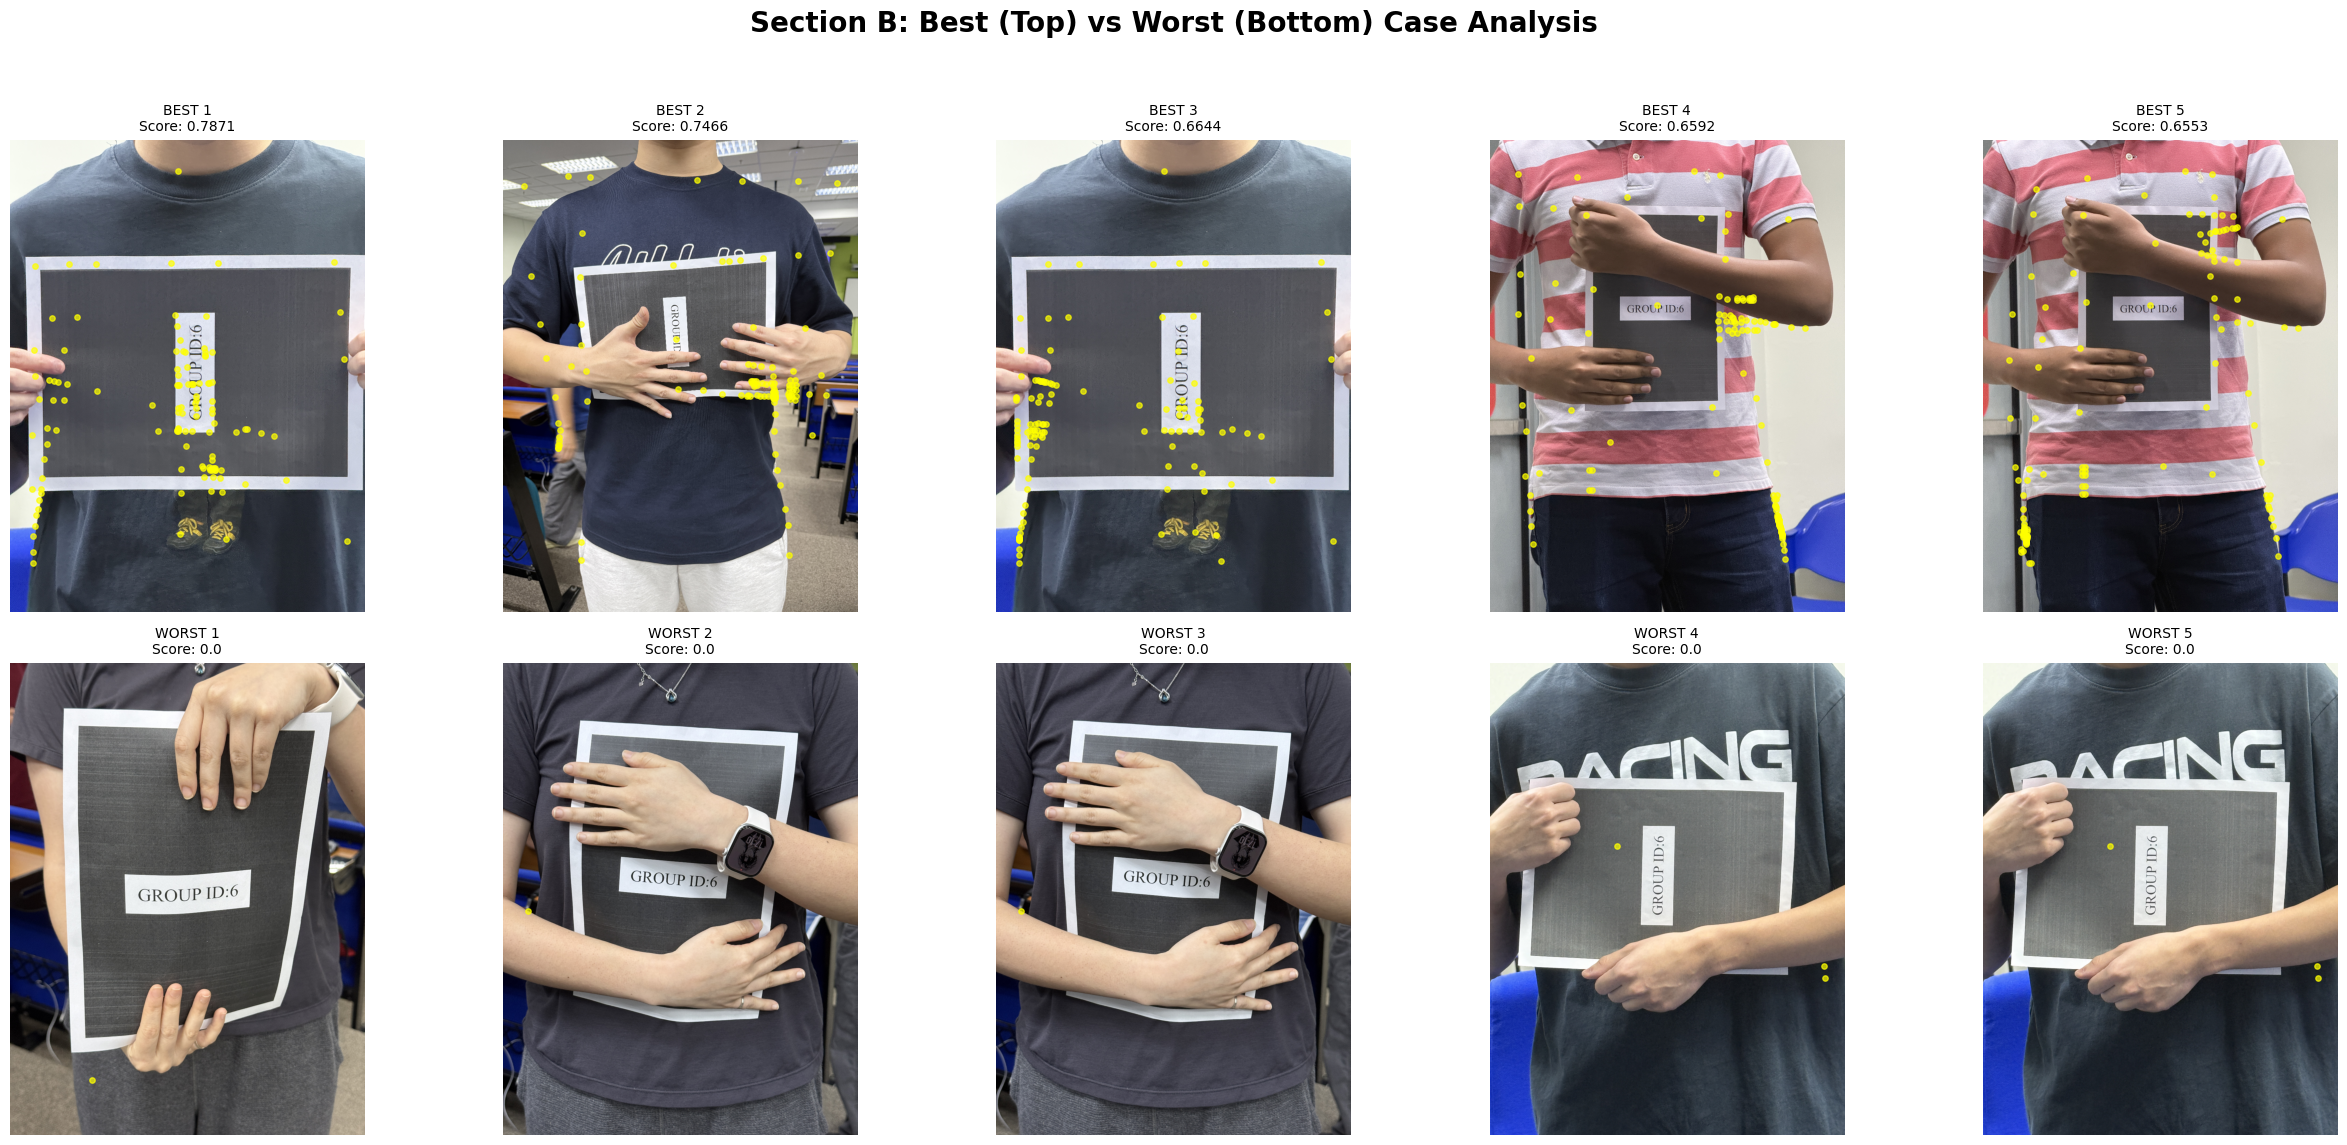

In [ ]:
image_folder = Path("dbpics") 

#  Selection Logic
h1_results = [r for r in all_rows if r["method"] == "Astar_h1"]
# Sorting by score: Highest first for 'Best', Lowest first for 'Worst'
sorted_h1 = sorted(h1_results, key=lambda x: x["final_likelihood_score"], reverse=True)

# Ensure we have enough results to plot
num_to_plot = min(5, len(sorted_h1))
best_5 = sorted_h1[:num_to_plot]
worst_5 = sorted_h1[-num_to_plot:] if len(sorted_h1) >= 5 else []

#  Execution Grid
fig, axes = plt.subplots(2, 5, figsize=(25, 12))
fig.suptitle("Section B: Best (Top) vs Worst (Bottom) Case Analysis", fontsize=20, fontweight='bold')

for i in range(num_to_plot):
    # Process Best Cases
    case_b = best_5[i]
    img_p_best = image_folder / case_b["image"]
    
    # Re-run search logic for visualization 
    cands_b, mask_b, w_b, h_b = preprocess_candidates(img_p_best)
    _, rect_b, _ = astar_partBC(cands_b, mask_b, w_b, h_b, use_h2=False)
    
    plot_search_result(img_p_best, rect_b, cands_b, 
                       f"BEST {i+1}\nScore: {case_b['final_likelihood_score']:.3f}", axes[0, i])
    
    # Process Worst Cases
    if i < len(worst_5):
        case_w = worst_5[i]
        img_p_worst = image_folder / case_w["image"]
        cands_w, mask_w, w_w, h_w = preprocess_candidates(img_p_worst)
        _, rect_w, _ = astar_partBC(cands_w, mask_w, w_w, h_w, use_h2=False)
        
        plot_search_result(img_p_worst, rect_w, cands_w, 
                           f"WORST {i+1}\nScore: {case_w['final_likelihood_score']:.3f}", axes[1, i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

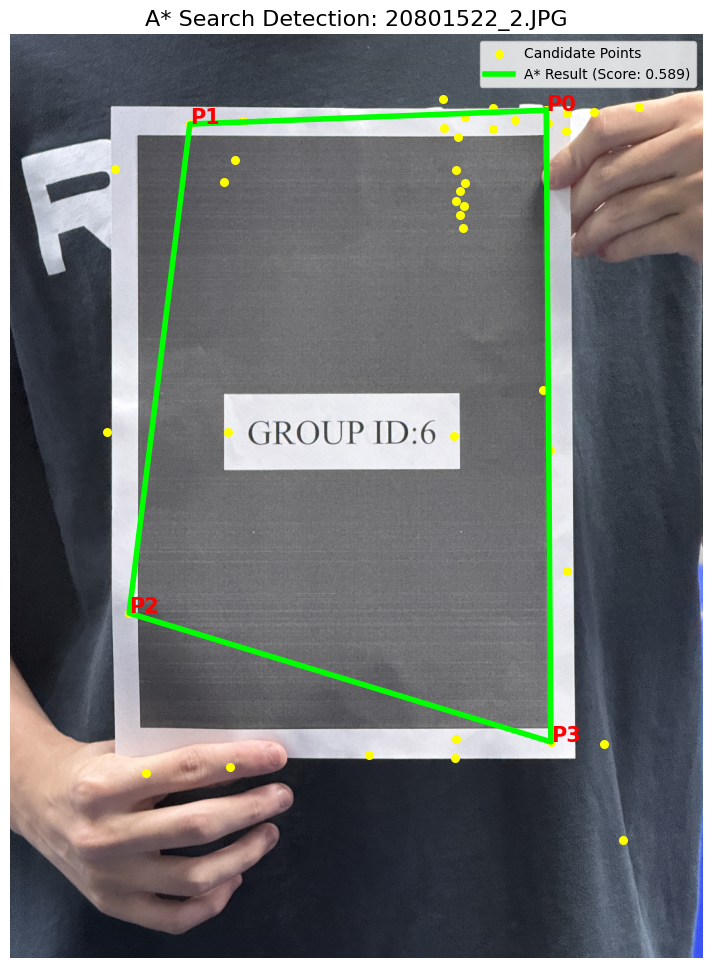

In [ ]:
# best performing image from the CSV
sample_img = "20801522_2.JPG"
img_folder = "dbpics" 

cands, mask, w, h = preprocess_candidates(Path(img_folder) / sample_img, max_candidates=40)
res = astar_partD(cands, mask, w, h, use_h2=False, goal_threshold=0.25)

# Render the output
plt.figure(figsize=(10, 12))
img = cv2.imread(str(Path(img_folder) / sample_img))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (1050, 1400)) # Match target dimensions
plt.imshow(img)

# Plot all candidate points in yellow
pts = np.array(cands)
plt.scatter(pts[:, 0], pts[:, 1], c='yellow', s=30, label='Candidate Points')

# Plot the A* result in lime green 
if res['best_rect'] is not None:
    rect = np.vstack([res['best_rect'], res['best_rect'][0]])
    plt.plot(rect[:, 0], rect[:, 1], c='lime', linewidth=4, label=f"A* Result (Score: {res['best_score']:.3f})")
    for i, pt in enumerate(res['best_rect']):
        plt.text(pt[0], pt[1], f'P{i}', color='red', fontsize=15, fontweight='bold')

plt.title(f"A* Search Detection: {sample_img}", fontsize=16)
plt.legend()
plt.axis('off')
plt.show()